### SMILES to odour descriptors for the M2OR ligands

Annotates every non-mixture M2OR compound with the odour descriptors recorded for it in the two
Pyrfume archives — Leffingwell (a controlled 113-term vocabulary) and GoodScents (free text).

In [1]:
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyrfume as pf
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import squareform

sys.path.append("../scripts")
from plotting_functions import custom_plots

%config InlineBackend.figure_formats = ["svg"]
plt.rcParams.update(custom_plots())

CHEMICALS = Path.cwd()
ODOR_DIR = CHEMICALS / "odor_datasets"
ODOR_DIR.mkdir(exist_ok=True, parents=True)

M2OR_PAIRS = CHEMICALS.parent / "Data" / "m2or_pairs.csv"
OUT_CSV = ODOR_DIR / "inchi_odors_smiles.csv"


/home/izirdeli/anaconda3/envs/or-evo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### The M2OR compounds

In [2]:
m2or = pd.read_csv(M2OR_PAIRS, sep=None, engine="python")

compounds = (
    m2or[m2or["Mixture"] != "mixture"][["InChIKey", "SMILES"]]
    .drop_duplicates(subset=["SMILES"], keep="first")
    .reset_index(drop=True)
)

print(f"m2or pairs            : {len(m2or):,}")
print(f"non-mixture compounds : {len(compounds):,}")
compounds.head()

m2or pairs            : 53,444
non-mixture compounds : 754


,InChIKey,SMILES
0,XMGQYMWWDOXHJM-SNVBAGLBSA-N,CC1=CC[C@H](CC1)C(=C)C
1,ULDHMXUKGWMISQ-VIFPVBQESA-N,CC1=CC[C@@H](CC1=O)C(=C)C
2,NOOLISFMXDJSKH-AEJSXWLSSA-N,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C
3,LRHPLDYGYMQRHN-UHFFFAOYSA-N,CCCCO
4,RWNUSVWFHDHRCJ-UHFFFAOYSA-N,CCCCOCC(C)O


### Odour tags per molecule

All odour tags are taken from both archives. Leffingwell stores them as a binary
molecule × descriptor matrix; GoodScents as a semicolon-separated string, with the molecule
reached through the CID.

In [3]:
stim_leff = pf.load_data("leffingwell/stimuli.csv")
beh_leff = pf.load_data("leffingwell/behavior.csv")
stim_gs = pf.load_data("goodscents/stimuli.csv")
beh_gs = pf.load_data("goodscents/behavior.csv")
mol_gs = pf.load_data("goodscents/molecules.csv")

leffingwell = (
    stim_leff[["IsomericSMILES"]]
    .assign(odors_leff=beh_leff.apply(lambda row: ", ".join(beh_leff.columns[row == 1]), axis=1))
    .drop_duplicates(subset=["IsomericSMILES"], keep="first")
)

goodscents = stim_gs[["CID"]].merge(
    mol_gs[["IsomericSMILES"]], left_on="CID", right_index=True, how="left"
)
goodscents["odors_gs"] = beh_gs["Descriptors"].str.replace(";", ", ", regex=False)
goodscents = goodscents.drop_duplicates(subset=["IsomericSMILES"], keep="first")[
    ["IsomericSMILES", "odors_gs"]
]

print(f"leffingwell molecules : {len(leffingwell):,}  ({beh_leff.shape[1]} controlled descriptors)")
print(f"goodscents  molecules : {len(goodscents):,}")

leffingwell molecules : 3,522  (113 controlled descriptors)
goodscents  molecules : 4,565


### Join the two archives

In [4]:
pyrfume_odors = leffingwell.merge(goodscents, on="IsomericSMILES", how="outer")

both = pyrfume_odors["odors_leff"].notna() & pyrfume_odors["odors_gs"].notna()
print(f"molecules in either archive : {len(pyrfume_odors):,}")
print(f"  described by both         : {both.sum():,}")
print(f"  leffingwell only          : {(pyrfume_odors['odors_leff'].notna() & ~both).sum():,}")
print(f"  goodscents only           : {(pyrfume_odors['odors_gs'].notna() & ~both).sum():,}")

molecules in either archive : 5,862
  described by both         : 2,225
  leffingwell only          : 1,297
  goodscents only           : 2,336


In [5]:
ODOR_VOCABULARY = frozenset({
    "acidic", "alcoholic", "aldehydic", "alliaceous", "almond", "amber", "animal", "anise",
    "anisic", "apple", "apricot", "aromatic", "balsamic", "banana", "beefy", "bergamot",
    "berry", "brandy", "bready", "brothy", "brown", "burnt", "buttery", "cabbage",
    "camphoreous", "caramellic", "cedar", "celery", "cheesy", "chemical", "cherry",
    "chicken", "chocolate", "cinnamon", "citrus", "clean", "clove", "cocoa", "coconut",
    "coffee", "cognac", "cooked", "cooling", "cortex", "coumarinic", "creamy", "cucumber",
    "dairy", "dry", "earthy", "estery", "ethereal", "fatty", "fermented", "fishy", "floral",
    "fresh", "fruity", "garlic", "gasoline", "geranium", "grape", "grapefruit", "grassy",
    "green", "hawthorn", "hay", "hazelnut", "herbal", "honey", "horseradish", "hyacinth",
    "jammy", "jasmine", "juicy", "ketonic", "lactonic", "lavender", "leafy",
    "leathery", "lemon", "lily", "malty", "marine", "meaty", "medicinal", "melon",
    "mentholic", "metallic", "milky", "minty", "muguet", "mushroom", "musk",
    "musty", "natural", "nutty", "odorless", "oily", "onion", "orange", "orangeflower",
    "orris", "ozone", "peach", "pear", "peppery", "phenolic", "pine", "pineapple", "plum",
    "popcorn", "potato", "powdery", "pungent", "radish", "raspberry", "ripe", "roasted",
    "rose", "rummy", "savory", "sharp", "smoky", "soapy", "solvent", "sour", "spicy",
    "strawberry", "sulfurous", "sweet", "tea", "terpenic", "tobacco", "tomato", "tropical",
    "vanilla", "vegetable", "violet", "warm", "waxy", "weedy", "winey", "woody",
})

# spelling and form variants of one percept, folded in before the filter.
DESCRIPTOR_ALIASES = {"jasmin": "jasmine", "mint": "minty", "rum": "rummy"}
assert not (set(DESCRIPTOR_ALIASES) & ODOR_VOCABULARY)
assert set(DESCRIPTOR_ALIASES.values()) <= ODOR_VOCABULARY

print(f"vocabulary: {len(ODOR_VOCABULARY)} descriptors  ({len(DESCRIPTOR_ALIASES)} aliases folded in)")

vocabulary: 144 descriptors  (3 aliases folded in)


### Build and export

Each compound's `Odors` is the union of what the two archives say about it, restricted to the
vocabulary.

In [6]:
def odor_tags(from_leffingwell, from_goodscents):
    """Union two descriptor strings in source order, keeping vocabulary terms only."""
    seen, tags = set(), []
    for descriptors in (from_leffingwell, from_goodscents):
        if pd.isna(descriptors):
            continue
        for tag in (t.strip() for t in str(descriptors).split(",")):
            tag = DESCRIPTOR_ALIASES.get(tag, tag)
            if tag in ODOR_VOCABULARY and tag not in seen:
                seen.add(tag)
                tags.append(tag)
    return ", ".join(tags) if tags else pd.NA


def descriptor_set(odors):
    if pd.isna(odors):
        return frozenset()
    return frozenset(t.strip() for t in str(odors).split(",") if t.strip())


annotated = compounds.merge(
    pyrfume_odors, left_on="SMILES", right_on="IsomericSMILES", how="left"
)
assert len(annotated) == len(compounds), "the join duplicated compounds"

annotated["Odors"] = [
    odor_tags(leff, gs)
    for leff, gs in zip(annotated["odors_leff"], annotated["odors_gs"])
]
tagsets = [descriptor_set(s) for s in annotated["Odors"]]

odor_map = annotated[["InChIKey", "SMILES", "Odors"]]
odor_map.to_csv(OUT_CSV, index=False)

print(f"wrote {OUT_CSV.relative_to(CHEMICALS)}  ({len(odor_map)} compounds)")
print(f"  with descriptors : {odor_map['Odors'].notna().sum()}")
print(f"  without          : {odor_map['Odors'].isna().sum()}")
odor_map.head()

wrote odor_datasets/inchi_odors_smiles.csv  (754 compounds)
  with descriptors : 575
  without          : 179


,InChIKey,SMILES,Odors
0,XMGQYMWWDOXHJM-SNVBAGLBSA-N,CC1=CC[C@H](CC1)C(=C)C,"herbal, orange, peppery, terpenic, pine"
1,ULDHMXUKGWMISQ-VIFPVBQESA-N,CC1=CC[C@@H](CC1=O)C(=C)C,"minty, bready, spicy"
2,NOOLISFMXDJSKH-AEJSXWLSSA-N,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C,mentholic
3,LRHPLDYGYMQRHN-UHFFFAOYSA-N,CCCCO,"alcoholic, solvent, winey, sweet, fermented, o..."
4,RWNUSVWFHDHRCJ-UHFFFAOYSA-N,CCCCOCC(C)O,<NA>


### The odorant universe

The 5,962 molecules `01_build_universe.py` reads: M2OR plus both archives, desalted and
keyed on a recomputed InChIKey.

In [ ]:
REFERENCE_SETS = CHEMICALS / "data" / "reference_sets.csv"

sys.path.append(str(CHEMICALS))
import chemspace as cs

sources = {
    "in_m2or": compounds["SMILES"],
    "in_leffingwell": leffingwell["IsomericSMILES"],
    "in_goodscents": goodscents["IsomericSMILES"],
}

universe = pd.DataFrame(
    [(str(s), flag) for flag, series in sources.items() for s in series.dropna()],
    columns=["smiles", "source"],
)

parents = {s: cs.to_parent(s) for s in universe["smiles"].unique()}
universe["parent"] = universe["smiles"].map(parents)
universe = universe[universe["parent"].notna()]
universe["smiles_can"] = universe["parent"].map(lambda p: p[0])
universe["inchikey"] = universe["parent"].map(lambda p: p[1])

# Three molecules reach us as different tautomers of one InChIKey. Sorting keeps the
# representative SMILES the same on every run.
universe = universe.sort_values(["inchikey", "smiles_can"])

reference_sets = (
    universe.pivot_table(index="inchikey", columns="source", aggfunc="size", fill_value=0)
    .reindex(columns=list(sources), fill_value=0)
    .gt(0).astype(int).reset_index()
)
reference_sets["smiles_can"] = reference_sets["inchikey"].map(
    universe.drop_duplicates("inchikey").set_index("inchikey")["smiles_can"]
)
reference_sets["is_odorant"] = 1
reference_sets = reference_sets[["inchikey", "smiles_can", *sources, "is_odorant"]]
reference_sets.to_csv(REFERENCE_SETS, index=False)

print(f"odorant universe : {len(reference_sets):,}")
for flag in sources:
    print(f"  {flag:16s} {int(reference_sets[flag].sum()):,}")

### Descriptor co-occurrence

Which descriptors are applied to the same molecules, as Jaccard (bounded 0–1, insensitive to how
common the two terms are) and lift (observed over what independence predicts, more sensitive for
rare terms). Descriptors carried by fewer than five molecules are dropped.

In [7]:
def cooccurrence(tagsets, min_molecules=5):
    """Descriptor x descriptor co-occurrence over molecules.

    Returns the co-occurrence counts, Jaccard and lift matrices, and the marginal
    frequency of each descriptor (the number of molecules carrying it).
    """
    frequency = Counter(t for ts in tagsets for t in ts)
    vocabulary = sorted(t for t, n in frequency.items() if n >= min_molecules)
    position = {t: i for i, t in enumerate(vocabulary)}

    incidence = np.zeros((len(tagsets), len(vocabulary)))
    for row, ts in enumerate(tagsets):
        for tag in ts:
            if tag in position:
                incidence[row, position[tag]] = 1

    counts = incidence.T @ incidence          # diagonal = marginal frequency
    marginal = np.diag(counts).copy()
    union = marginal[:, None] + marginal[None, :] - counts
    expected = np.outer(marginal, marginal)
    with np.errstate(divide="ignore", invalid="ignore"):
        jaccard = np.where(union > 0, counts / union, 0.0)
        lift = np.where(expected > 0, counts * len(tagsets) / expected, 0.0)

    frame = lambda M: pd.DataFrame(M, index=vocabulary, columns=vocabulary)
    return (frame(counts), frame(jaccard), frame(lift),
            pd.Series(marginal, index=vocabulary, name="molecules").astype(int))


described = [ts for ts in tagsets if ts]
counts, jaccard, lift, marginal = cooccurrence(described)

print(f"molecules with at least one descriptor : {len(described)}")
print(f"descriptors on >= 5 molecules          : {len(marginal)}")
print(f"most common: {', '.join(marginal.sort_values(ascending=False).head(8).index)}")

molecules with at least one descriptor : 575
descriptors on >= 5 molecules          : 136
most common: sweet, fruity, green, floral, fatty, fresh, waxy, herbal


Ordered by average-linkage clustering on 1-Jaccard, so descriptors that travel together sit
together. Lower triangle only: the matrix is symmetric and the diagonal is trivially 1.

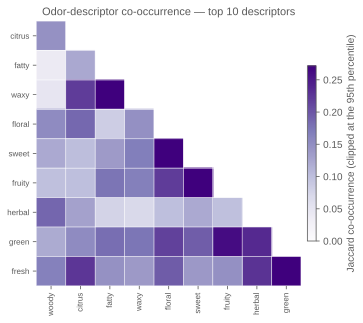

In [ ]:
N_SHOWN = 10
top = marginal.sort_values(ascending=False).head(N_SHOWN).index.tolist()
M = jaccard.loc[top, top].values

distance = 1 - M
np.fill_diagonal(distance, 0.0)
distance = (distance + distance.T) / 2        # enforce symmetry for squareform
order = leaves_list(linkage(squareform(distance, checks=False), method="average"))
labels = [top[i] for i in order]
M = M[np.ix_(order, order)]

M = np.where(np.tril(np.ones_like(M), k=-1).astype(bool), M, np.nan)

# a strict lower triangle leaves the first row and the last column empty; drop them
M = M[1:, :-1]
row_labels, col_labels = labels[1:], labels[:-1]

cmap = plt.get_cmap("Purples").copy()     
cmap.set_bad("white")

fig, ax = plt.subplots(figsize=(0.22 * N_SHOWN + 3, 0.22 * N_SHOWN + 2.5))
im = ax.imshow(M, cmap=cmap, vmin=0, vmax=np.nanpercentile(M[M > 0], 95))
ax.set_xticks(range(len(col_labels)), col_labels, rotation=90, fontsize=8)
ax.set_yticks(range(len(row_labels)), row_labels, fontsize=8)
ax.set_xticks(np.arange(-0.5, len(col_labels)), minor=True)
ax.set_yticks(np.arange(-0.5, len(row_labels)), minor=True)
ax.grid(which="minor", color="white", lw=0.6)
ax.tick_params(which="minor", length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02,
             label="Jaccard co-occurrence (clipped at the 95th percentile)")
ax.set_title(f"Odor-descriptor co-occurrence — top {N_SHOWN} descriptors", fontsize=11)
fig.tight_layout()
plt.show()

The strongest pairs by each measure. Jaccard favours pairs that are common *and* overlapping;
lift surfaces the rarer, more specific pairings.

In [9]:
pairs = [
    (a, b, counts.loc[a, b], jaccard.loc[a, b], lift.loc[a, b])
    for i, a in enumerate(marginal.index) for b in marginal.index[i + 1:]
    if counts.loc[a, b] > 0
]
pairs = pd.DataFrame(pairs, columns=["descriptor A", "descriptor B", "molecules", "jaccard", "lift"])
pairs["molecules"] = pairs["molecules"].astype(int)

print("strongest overlap (Jaccard):")
print(pairs.nlargest(12, "jaccard").to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print("\nmost specific pairings (lift, on pairs sharing >= 5 molecules):")
print(pairs[pairs["molecules"] >= 5].nlargest(12, "lift")
           .to_string(index=False, float_format=lambda x: f"{x:.3f}"))

strongest overlap (Jaccard):
descriptor A descriptor B  molecules  jaccard   lift
  alliaceous       garlic         13    0.591 24.589
    bergamot     lavender          4    0.500 65.714
       onion    sulfurous         25    0.490 10.417
      garlic        onion         16    0.485 16.140
  alliaceous        onion         13    0.394 15.573
       meaty    sulfurous         23    0.371  7.372
      garlic    sulfurous         17    0.354 11.184
      fruity        sweet        118    0.352  1.341
        pine     terpenic          8    0.348 19.167
       fatty         waxy         52    0.342  2.884
     cooling    mentholic          5    0.333 29.040
      animal         musk         15    0.319  9.060

most specific pairings (lift, on pairs sharing >= 5 molecules):
descriptor A descriptor B  molecules  jaccard   lift
     cooling    mentholic          5    0.333 29.040
  alliaceous       garlic         13    0.591 24.589
    cucumber        orris          5    0.278 21.780
    h